# Arboles de decision

# Random Forest

Cómo funciona:

- Construye muchos árboles independientes entre sí.

- Cada árbol da su predicción y el resultado final es el promedio (en regresión) o el voto mayoritario (en clasificación).

##Idea clave:

- "La sabiduría del grupo": cada árbol es diferente y juntos compensan sus errores.

## Ventaja:

- Robusto, fácil de usar, casi no se sobreajusta.

## Desventaja:

- No siempre alcanza la máxima precisión posible porque los árboles no se corrigen entre sí.
---

# Gradient Boosting

## Cómo funciona:

- Construye árboles uno después del otro.

- Cada nuevo árbol intenta corregir los errores que hicieron los anteriores.

- Se suman las correcciones poco a poco hasta mejorar mucho la predicción.

## Idea clave:

- "Aprender de los errores paso a paso".

## Ventaja:

- Suele lograr más precisión que Random Forest si se entrena bien.

## Desventaja:

- Más sensible a los parámetros (si no se ajusta bien puede sobreajustar).

- Requiere más tiempo de cómputo.
---

# XGBoost
Es un algoritmo muy popular para hacer predicciones (tanto clasificación como regresión). Su nombre viene de eXtreme Gradient Boosting.

## La idea básica:

- Un árbol solo no es suficiente. Si usamos un único árbol de decisión, la predicción puede ser poco precisa.

- Construye muchos árboles, uno tras otro

- El primer árbol hace una predicción (con errores).

- El segundo árbol aprende a corregir los errores del primero.

- El tercero corrige los errores de los dos anteriores… y así sucesivamente.

- Cada nuevo árbol se suma al modelo. Al final, la predicción es la suma de todos los árboles, donde cada uno aporta un “ajuste” pequeño.

- Usa Gradient Boosting

- “Gradient” significa que se guía por la dirección del error (como cuando optimizamos en regresión lineal con gradiente descendente).

- Así, cada nuevo árbol se centra en reducir los errores más importantes.



## ¿Por qué XGBoost es tan bueno?

- Optimiza el cálculo (rápido).

- Incluye regularización (evita sobreajuste).

- Maneja datos grandes muy bien.

- Funciona muy bien con variables categóricas transformadas en dummies.

En resumen:
- XGBoost es como un “equipo de árboles” donde cada árbol corrige a los anteriores, y al final todos juntos hacen una predicción mucho más precisa que un árbol individual.

# **Si tuvieras que adivinar el peso de una caja, Cómo lo harías?**

## Random Forest

- Llamas a 100 amigos.

- Cada uno intenta adivinar el peso por su cuenta.

- Algunos fallan mucho, otros aciertan más… pero cuando promedias las respuestas, el resultado suele estar bastante bien.
- Es la sabiduría del grupo.

## Gradient Boosting

- En lugar de muchos amigos, tienes un solo amigo que intenta adivinar varias veces.

- La primera vez se equivoca mucho.

- Luego corrige su error: “ok, estaba demasiado alto, voy a ajustar hacia abajo”.

- Repite este proceso, aprendiendo de cada error, hasta acercarse bastante al peso real.
- Es aprender paso a paso de los propios errores.

## XGBoost

- Ahora tienes ese mismo amigo, pero con calculadora científica y experiencia de años como tasador.

- No solo corrige los errores, sino que lo hace de la forma más eficiente posible (no pierde tiempo corrigiendo de más o de menos).

- Además, se asegura de no complicarse demasiado para evitar confusiones.
- Es Gradient Boosting con turbo: rápido, organizado y más preciso.


## Resumen

- Random Forest → muchos opinan y sacas un promedio.

- Gradient Boosting → uno solo aprende de sus errores paso a paso.

- XGBoost → ese mismo, pero con herramientas y estrategia para aprender mucho más rápido y sin exceso de confianza.

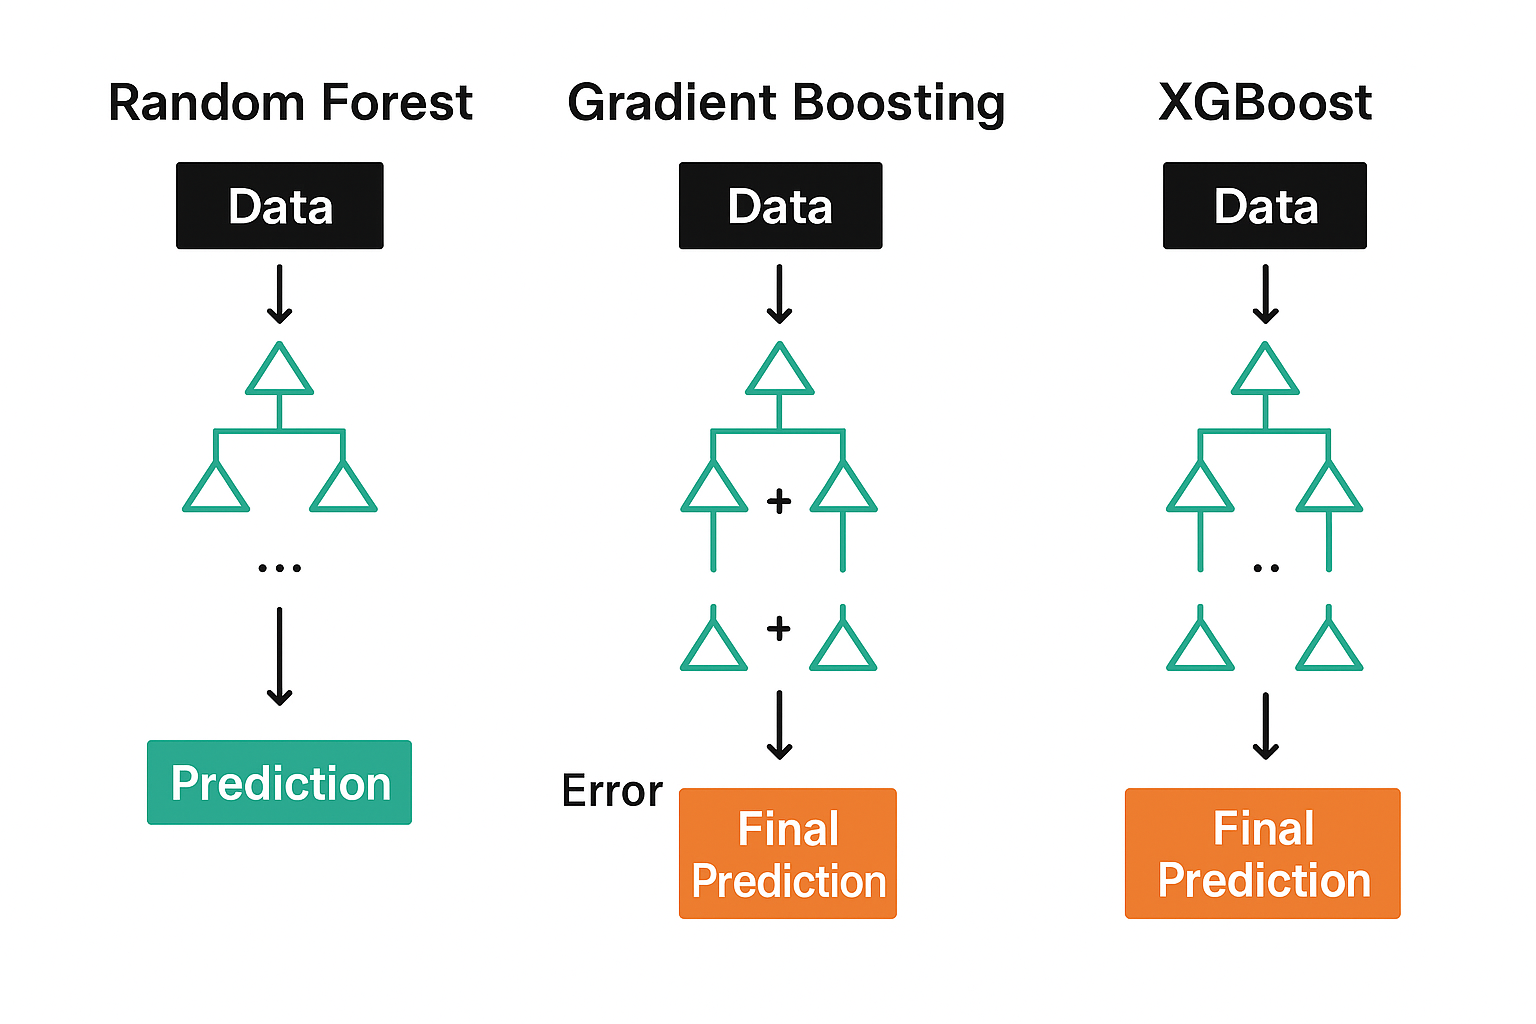

# Ejercicio

In [1]:
from sklearn.datasets import fetch_california_housing

df= fetch_california_housing()

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude


In [2]:
import pandas as pd

df_data = pd.DataFrame(df.data, columns=df.feature_names)
df_data['target'] = df.target
display(df_data.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


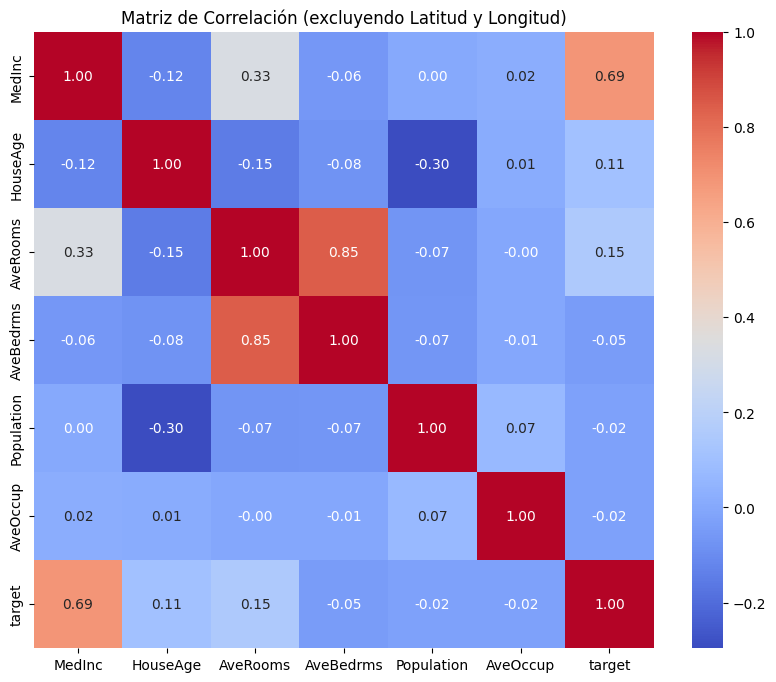

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Excluir las variables 'Latitude' y 'Longitude' del DataFrame
df_filtered = df_data.drop(columns=['Latitude', 'Longitude'])

# Calcular la matriz de correlación
correlation_matrix = df_filtered.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación (excluyendo Latitud y Longitud)')
plt.show()

La variable que mas correlacion tiene con el target es Med Income: dependiendo el ingreso promedio de las personas que viven en la zona, el precio de la casa sube

**Modelo de random forest**

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Separate features (X) and target (y) (PARTICION DE LOS DATOS X , Y)
X = df_data.drop('target', axis=1)
y = df_data['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate R-squared (R2) for Random Forest
r2_rf = r2_score(y_test, y_pred_rf)

print(f"R-squared (R2) for Random Forest: {r2_rf:.2f}")

R-squared (R2) for Random Forest: 0.81


**Modelo XG boost**

In [6]:
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Gradient Boosting Regressor model
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gbr = gbr_model.predict(X_test)

# Calculate performance metrics for Gradient Boosting
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting model trained successfully!")
print(f"Mean Squared Error (MSE) for Gradient Boosting: {mse_gbr:.2f}")
print(f"R-squared (R2) for Gradient Boosting: {r2_gbr:.2f}")



Gradient Boosting model trained successfully!
Mean Squared Error (MSE) for Gradient Boosting: 0.29
R-squared (R2) for Gradient Boosting: 0.78


**Gradient boosting**

In [ ]:
# Initialize and train the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate performance metrics for XGBoost
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost model trained successfully!")
print(f"Mean Squared Error (MSE) for XGBoost: {mse_xgb:.2f}")
print(f"R-squared (R2) for XGBoost: {r2_xgb:.2f}")

XGBoost model trained successfully!
Mean Squared Error (MSE) for XGBoost: 0.30
R-squared (R2) for XGBoost: 0.77


el modelo que mejor rendimiento tiene es el de random forest sin hacer ajuste de hiperparametros, entonces ese es el que vamos a usar

Es interesante observar que Random Forest tuvo un rendimiento ligeramente mejor en este caso específico con los parámetros por defecto. Si bien Gradient Boosting y XGBoost a menudo logran una mayor precisión con un ajuste adecuado, podría haber varias razones por las que Random Forest los superó aquí:

*   **Hiperparámetros por defecto:** Los hiperparámetros por defecto para Gradient Boosting y XGBoost pueden no ser óptimos para este conjunto de datos. Estos algoritmos suelen ser más sensibles al ajuste de hiperparámetros que Random Forest. La configuración por defecto de Random Forest suele ser bastante robusta.
*   **Características del conjunto de datos:** Para algunos conjuntos de datos, el enfoque de promediación de Random Forest (que reduce la varianza) podría ser más efectivo que la corrección secuencial de errores de Gradient Boosting y XGBoost (que reduce el sesgo), especialmente si el sesgo introducido por los árboles individuales ya es bajo.
*   **Sobreajuste:** Sin ajuste de hiperparámetros, Gradient Boosting y XGBoost pueden ser más propensos a sobreajustar los datos de entrenamiento en comparación con Random Forest, que inherentemente reduce el sobreajuste a través de la aleatoriedad en la construcción de árboles y la promediación.

En muchos escenarios del mundo real, después del ajuste de hiperparámetros, es probable que Gradient Boosting y XGBoost superen a Random Forest en rendimiento. Sin embargo, Random Forest suele ser un modelo de referencia sólido debido a su simplicidad y buen rendimiento con la configuración por defecto.

Gradient boosting y XGbost pueden tener mejor rendimiento pero hay que hacer ajuste de hiperparametros (ayudar de definir la taza de aprendizaje y la profundidad con los que van a trabajar los modelos)

# Optimización de hiperparametros


In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

In [9]:
param_grid_gbr = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}



Entre mayor profunidad, puede mejorar el desempeño.
En cuanto a la tasa de aprendizaje si es muy pequeña se demora mucho y si es muy grande se puede saltar el error

Configurar GridSearchCV para Gradient Boosting y XGBoost usando los parametros y estimadores definidos.



In [10]:

gbr = GradientBoostingRegressor(random_state=42)


xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)


grid_search_gbr = GridSearchCV(estimator=gbr, param_grid=param_grid_gbr, cv=5)


grid_search_xgb = GridSearchCV(estimator=xgb_reg, param_grid=param_grid_xgb, cv=5)



Se ajusta el objeto de búsqueda a los datos de entrenamiento para encontrar la mejor combinación de hiperparámetros para ambos modelos.


In [11]:
# Fit the GridSearchCV object to the training data for Gradient Boosting
grid_search_gbr.fit(X_train, y_train)

# Fit the GridSearchCV object to the training data for XGBoost
grid_search_xgb.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 200]})

## Evaluar los modelos con los mejores hiperparámetros



In [12]:
from sklearn.metrics import mean_squared_error, r2_score

# Get the best estimator for Gradient Boosting
best_gbr_model = grid_search_gbr.best_estimator_

# Make predictions on the test set using the best Gradient Boosting model
y_pred_gbr_tuned = best_gbr_model.predict(X_test)

# Calculate performance metrics for the tuned Gradient Boosting model
mse_gbr_tuned = mean_squared_error(y_test, y_pred_gbr_tuned)
r2_gbr_tuned = r2_score(y_test, y_pred_gbr_tuned)

print("Tuned Gradient Boosting model performance:")
print(f"Mean Squared Error (MSE): {mse_gbr_tuned:.2f}")
print(f"R-squared (R2): {r2_gbr_tuned:.2f}")
print("-" * 30)

Tuned Gradient Boosting model performance:
Mean Squared Error (MSE): 0.22
R-squared (R2): 0.83
------------------------------


In [13]:
# Obtener el mejor estimador para XGBoost
best_xgb_model = grid_search_xgb.best_estimator_

# hacer las predicciones en test set
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Calcular las metricas de desempeño
mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("Tuned XGBoost model performance:")
print(f"Mean Squared Error (MSE): {mse_xgb_tuned:.2f}")
print(f"R-squared (R2): {r2_xgb_tuned:.2f}")

Tuned XGBoost model performance:
Mean Squared Error (MSE): 0.21
R-squared (R2): 0.84


**IMPORTANCIA DE AJUSTE DE HIPERPARAMETROS**

- La optimización de hiperparámetros mejoró el desempeño tanto del modelo de Gradient Boosting como del de XGBoost.
- El modelo ajustado de Gradient Boosting alcanzó un MSE de 0.22 y un R² de 0.83 en el conjunto de prueba.
- El modelo ajustado de XGBoost obtuvo un MSE de 0.21 y un R² de 0.84, superando ligeramente al modelo ajustado de Gradient Boosting.

- Ambos modelos de boosting optimizados mostraron un mejor rendimiento que el modelo de Random Forest con parámetros por defecto (los valores de MSE y R² no se reportaron explícitamente para este último, pero la comparación indica un desempeño inferior).

---

Los mejores hiperparámetros encontrados para el modelo de Gradient Boosting fueron:
**`{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}`**

Los mejores hiperparámetros encontrados para el modelo de XGBoost fueron:
**`{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}`**

**IMPORTANTE DEJAR ESTO ESPECIFICADO**

In [14]:
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score


gbr_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)


mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)


print(f"Mean Squared Error (MSE) for Gradient Boosting: {mse_gbr:.2f}")
print(f"R-squared (R2) for Gradient Boosting: {r2_gbr:.2f}")


Mean Squared Error (MSE) for Gradient Boosting: 0.22
R-squared (R2) for Gradient Boosting: 0.83


In [15]:

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, learning_rate=0.2, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)


y_pred_xgb = xgb_model.predict(X_test)


mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)


print(f"Mean Squared Error (MSE) for XGBoost: {mse_xgb:.2f}")
print(f"R-squared (R2) for XGBoost: {r2_xgb:.2f}")

Mean Squared Error (MSE) for XGBoost: 0.21
R-squared (R2) for XGBoost: 0.84
